# Testing All Environment Functions and Functionality

## 1. Imports + Helper Settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from battery_env import BatteryEnv
import env_config            

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

## 2. Create Env + Quick Reset Sanity

In [2]:
env = BatteryEnv(config=env_config, publish_hour=12, episode_days=30, randomize_init_soc=True)

obs, info = env.reset(seed=123)

print("obs shape:", np.array(obs).shape)
print("reset info:", info)

# CURRENT row timestamps at reset:
idx0 = int(env.current_day_idxs[env.slot0])
print("idx0:", idx0)
print("delivery_ts0:", pd.Timestamp(env.delivery_ts[idx0]))
print("trade_ts0:", pd.Timestamp(env.trade_ts[idx0]))
print("tau0:", int(env.tau[idx0]))

env = BatteryEnv(env_config)

obs shape: (103,)
reset info: {'start_day': '2022-02-19T00:00:00.000000000', 'publish_hour': 12, 'episode_days': 30, 'init_soc': 0.5729407452992573}
idx0: 19870
delivery_ts0: 2022-02-19 00:00:00
trade_ts0: 2022-02-18 00:00:00
tau0: 1


## 3. Data Integrity Checks

In [3]:
from pathlib import Path

ROOT_DIR = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path.cwd().parents[0]
DATA_PATH = ROOT_DIR / "data" / "training_data.parquet"
df = pd.read_parquet(DATA_PATH).copy()

df["delivery_ts"] = pd.to_datetime(df["delivery_ts"])
df["delivery_date"] = pd.to_datetime(df["delivery_date"]).dt.floor("D")
df = df.sort_values("delivery_ts").reset_index(drop=True)

required = ["delivery_ts","delivery_date","tau","mid_price_gbp_mwh","da_price_gbp_mwh","carbon_gco2_kwh"]
missing = [c for c in required if c not in df.columns]
assert not missing, f"Missing columns: {missing}"

# 1) duplicates (most important)
dup_ts = df["delivery_ts"].duplicated().sum()
dup_day_tau = df.duplicated(subset=["delivery_date", "tau"]).sum()
print("Duplicate delivery_ts:", dup_ts)
print("Duplicate (delivery_date, tau):", dup_day_tau)

# 2) per-day slot count
counts = df.groupby("delivery_date").size()
print("Days with !=48 rows:", (counts != 48).sum())

# 3) per-day tau set must be 1..48
bad_tau_days = []
for d, g in df.groupby("delivery_date"):
    taus = sorted(g["tau"].astype(int).tolist())
    if taus != list(range(1,49)):
        bad_tau_days.append(d)
print("Days with wrong tau set:", len(bad_tau_days))

# 4) cadence check (30-min)
bad_cadence_days = []
for d, g in df.groupby("delivery_date"):
    g = g.sort_values("delivery_ts")
    if len(g) != 48:
        continue
    deltas = g["delivery_ts"].diff().dropna().dt.total_seconds() / 60
    if not np.all(deltas.values == 30):
        bad_cadence_days.append(d)
print("Days with bad cadence:", len(bad_cadence_days))

Duplicate delivery_ts: 0
Duplicate (delivery_date, tau): 0
Days with !=48 rows: 2
Days with wrong tau set: 2
Days with bad cadence: 0


## 4. Valid Day Selection

In [4]:
def get_valid_days(df):
    day_to_idx = df.groupby("delivery_date").indices
    valid = []
    day_indices = {}
    for d, idxs in day_to_idx.items():
        idxs = np.array(sorted(idxs), dtype=np.int64)
        if len(idxs) != 48:
            continue
        taus = df.loc[idxs, "tau"].to_numpy()
        if set(taus.tolist()) != set(range(1,49)):
            continue
        ts_day = df.loc[idxs, "delivery_ts"].to_numpy(dtype="datetime64[ns]")
        deltas = np.diff(ts_day).astype("timedelta64[m]").astype(int)
        if not np.all(deltas == 30):
            continue
        d64 = np.datetime64(pd.Timestamp(d).floor("D"))
        valid.append(d64)
        day_indices[d64] = idxs
    return np.array(sorted(valid), dtype="datetime64[ns]"), day_indices

valid_days, day_indices = get_valid_days(df)
print("valid days:", len(valid_days))
print("first 5:", valid_days[:5])

# Choose a 5-day window start
start_day = valid_days[0]
five_days = valid_days[:5]
print("5-day window:", five_days)

valid days: 728
first 5: ['2021-01-01T00:00:00.000000000' '2021-01-02T00:00:00.000000000'
 '2021-01-03T00:00:00.000000000' '2021-01-04T00:00:00.000000000'
 '2021-01-05T00:00:00.000000000']
5-day window: ['2021-01-01T00:00:00.000000000' '2021-01-02T00:00:00.000000000'
 '2021-01-03T00:00:00.000000000' '2021-01-04T00:00:00.000000000'
 '2021-01-05T00:00:00.000000000']


## 5. Run env for exactly 5 delivery days and collect a rollout dataframe

In [6]:
def heuristic_policy(env, obs, mode="price_only"):
    # obs layout:
    # [soc, id_price, ci, tau, p_prev, da_avail, planned_power_now] + 48 DA curve
    soc, id_price, ci, tau, p_prev, da_avail, planned_power = obs[:7]
    da_curve = obs[7:]  # length 48
    
    # Choose dispatch:
    # price-only: charge if cheap, discharge if expensive
    # carbon-aware: charge only when carbon low, discharge only when carbon high
    cheap = id_price < np.nanpercentile(env.id_price, 30)
    expensive = id_price > np.nanpercentile(env.id_price, 70)

    if mode == "price_only":
        if expensive and soc > env.SoC_min + 0.02:
            dispatch = env.n_power_levels - 1  # max discharge
        elif cheap and soc < env.SoC_max - 0.02:
            dispatch = 0  # max charge (since power_levels goes -Pmax..+Pmax)
        else:
            dispatch = env.n_power_levels // 2  # near zero
    else:
        # carbon-aware (simple): charge when CI low, discharge when CI high
        ci_low = ci < np.nanpercentile(env.ci, 30)
        ci_high = ci > np.nanpercentile(env.ci, 70)
        if expensive and ci_high and soc > env.SoC_min + 0.02:
            dispatch = env.n_power_levels - 1
        elif cheap and ci_low and soc < env.SoC_max - 0.02:
            dispatch = 0
        else:
            dispatch = env.n_power_levels // 2

    # Plan update (tomorrow plan): only meaningful when da_avail == 1
    # We'll write a naive plan: charge in lowest 12 DA slots, discharge in highest 12.
    plan_idx = env.n_power_levels // 2
    plan_slot = int(tau - 1)  # update "same slot index" (arbitrary but fine for testing)

    if da_avail > 0.5:
        # choose plan based on tomorrow's DA curve at that slot
        px = da_curve[plan_slot]
        # crude: if tomorrow DA is high -> plan discharge, low -> plan charge
        if px > np.nanpercentile(da_curve, 70):
            plan_idx = env.n_power_levels - 1
        elif px < np.nanpercentile(da_curve, 30):
            plan_idx = 0
        else:
            plan_idx = env.n_power_levels // 2

    return np.array([dispatch, plan_idx, plan_slot], dtype=int)

def rollout(env, days=5, seed=123, mode="price_only"):
    obs, info0 = env.reset(seed=seed)
    rows = []
    target_steps = days * 48

    for k in range(target_steps):
        action = heuristic_policy(env, obs, mode=mode)
        obs, r, term, trunc, info = env.step(action)

        rows.append({
            "k": k,
            "delivery_ts": info["delivery_ts"],
            "trade_ts": info["trade_ts"],
            "delivery_date": info["delivery_date"],
            "tau": info["tau"],

            "soc": info["soc"],
            "P_applied_MW": info["P_applied_MW"],
            "delta_soc": info["delta_soc"],

            "id_price_now": info["id_price_now"],
            "da_price_now": info["da_price_now"],
            "ci_now": info["ci_now"],

            "profit": info["profit_norm"],
            "carbon_penalty": info["carbon_penalty_norm"],
            "reward": r,

            "da_available": info["da_available"],
        })

        if term or trunc:
            break

    df_out = pd.DataFrame(rows)
    df_out["delivery_ts"] = pd.to_datetime(df_out["delivery_ts"])
    df_out["trade_ts"] = pd.to_datetime(df_out["trade_ts"])
    df_out["delivery_date"] = pd.to_datetime(df_out["delivery_date"]).dt.floor("D")
    return df_out

df_roll = rollout(env, days=5, seed=123, mode="price_only")
df_roll.head(), df_roll.tail(), df_roll["delivery_date"].nunique()

(   k         delivery_ts            trade_ts delivery_date  tau       soc  P_applied_MW  delta_soc  id_price_now  da_price_now  ci_now  \
 0  0 2022-02-19 00:00:00 2022-02-18 00:00:00    2022-02-19    1  0.572941           0.0        0.0    166.210007         110.0    48.0   
 1  1 2022-02-19 00:30:00 2022-02-18 00:30:00    2022-02-19    2  0.572941           0.0        0.0    160.169998         146.0    49.0   
 2  2 2022-02-19 01:00:00 2022-02-18 01:00:00    2022-02-19    3  0.572941           0.0        0.0    156.809998         138.0    54.0   
 3  3 2022-02-19 01:30:00 2022-02-18 01:30:00    2022-02-19    4  0.572941           0.0        0.0    138.649994         110.0    53.0   
 4  4 2022-02-19 02:00:00 2022-02-18 02:00:00    2022-02-19    5  0.572941           0.0        0.0    143.009995         110.0    54.0   
 
    profit  carbon_penalty  reward  da_available  
 0     0.0            -0.0     0.0         False  
 1     0.0            -0.0     0.0         False  
 2     0.0 

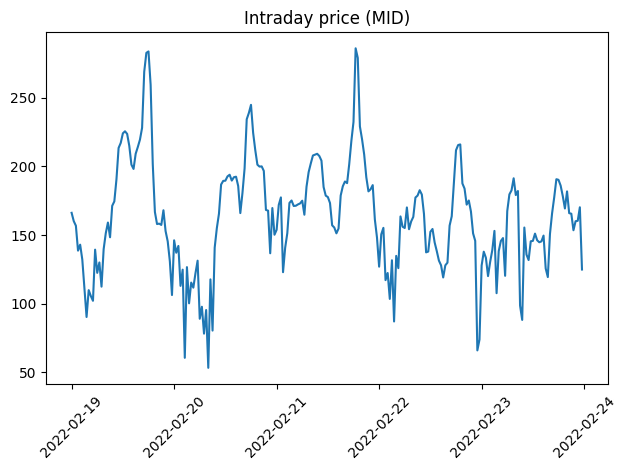

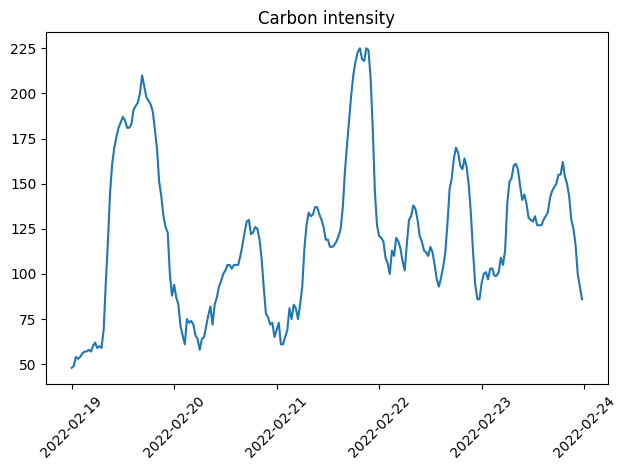

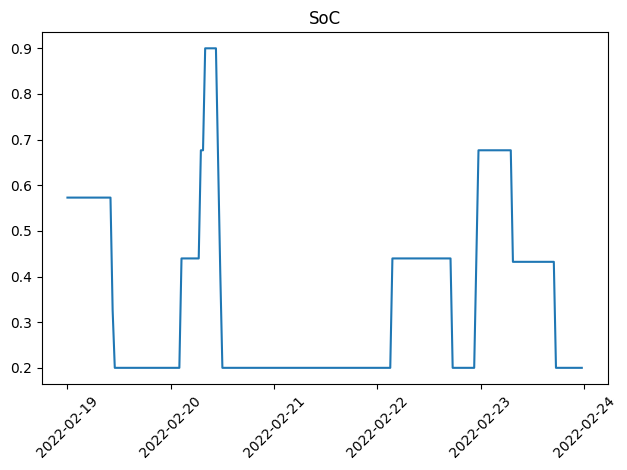

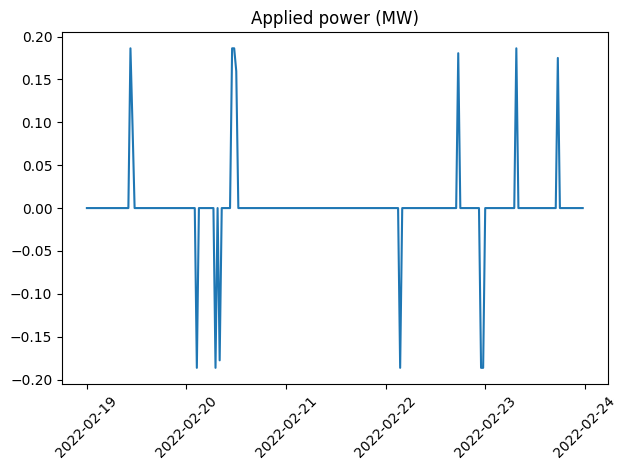

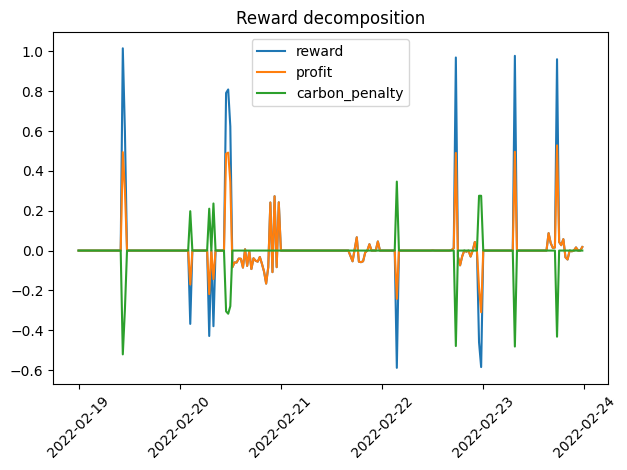

In [7]:
def plot_rollout(df):
    df = df.sort_values("delivery_ts").reset_index(drop=True)

    plt.figure()
    plt.plot(df["delivery_ts"], df["id_price_now"])
    plt.title("Intraday price (MID)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(df["delivery_ts"], df["ci_now"])
    plt.title("Carbon intensity")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(df["delivery_ts"], df["soc"])
    plt.title("SoC")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(df["delivery_ts"], df["P_applied_MW"])
    plt.title("Applied power (MW)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(df["delivery_ts"], df["reward"], label="reward")
    plt.plot(df["delivery_ts"], df["profit"], label="profit")
    plt.plot(df["delivery_ts"], df["carbon_penalty"], label="carbon_penalty")
    plt.legend()
    plt.title("Reward decomposition")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_rollout(df_roll)

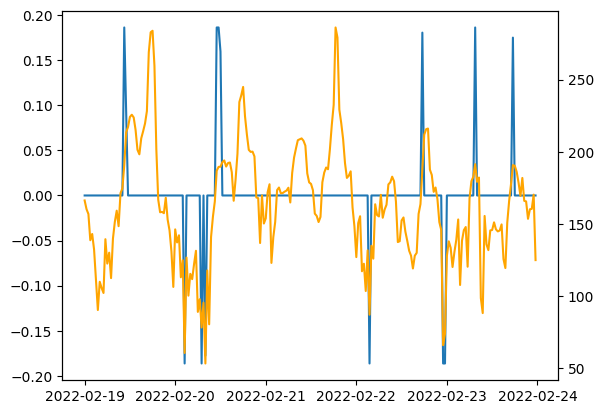

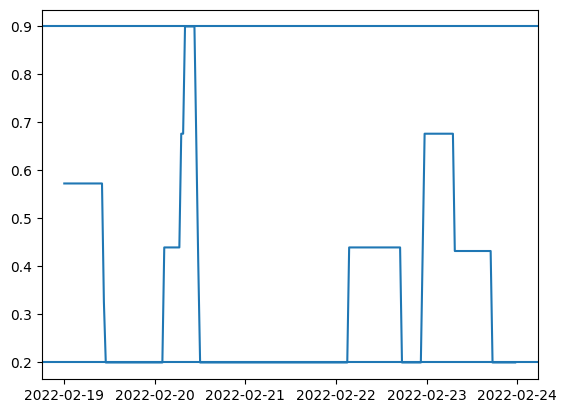

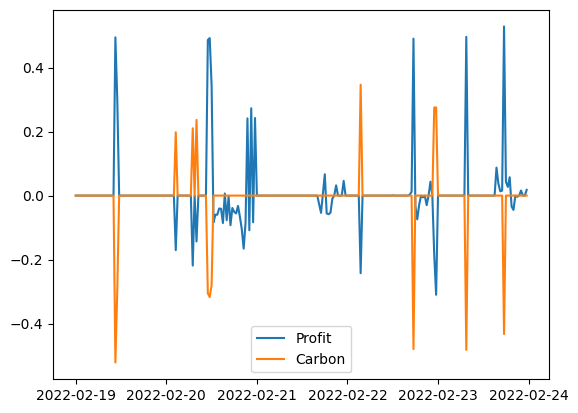

In [8]:
def plot_rollout_2(df):
    df = df.sort_values("delivery_ts").reset_index(drop=True)

    # Power vs price
    plt.plot(df["delivery_ts"], df["P_applied_MW"], label="Power")
    plt.twinx()
    plt.plot(df["delivery_ts"], df["id_price_now"], color="orange", label="ID price")

    # SoC trajectory
    plt.figure()
    plt.plot(df["delivery_ts"], df["soc"])
    plt.axhline(env.SoC_min)
    plt.axhline(env.SoC_max)

    # Profit vs carbon
    plt.figure()
    plt.plot(df["delivery_ts"], df["profit"], label="Profit")
    plt.plot(df["delivery_ts"], df["carbon_penalty"], label="Carbon")
    plt.legend()

plot_rollout_2(df_roll)
    

# 7. Reward Decomposition Checks

## 6.1. Profit term sanity with constant price

In [10]:
import numpy as np
import pandas as pd
from battery_env import BatteryEnv
import env_config

env = BatteryEnv(env_config)

# turn off carbon
env.lambda_ci = 0.0

obs, info = env.reset(seed=123)

rows = []
fails = []

N = 80

for t in range(N):
    a = env.action_space.sample()

    obs, reward, terminated, truncated, info = env.step(a)

    P_app = float(info["P_applied_MW"])
    dt = float(env.dt_hours)

    # planned power for *this* slot
    planned_idx = int(info["planned_idx_today"])
    P_plan = float(env.power_levels[planned_idx]) if planned_idx >= 0 else 0.0

    # prices
    da_price = float(info["da_price_now"])
    id_price = float(info["id_price_now"])

    # energies
    E_plan = P_plan * dt
    E_dev  = (P_app - P_plan) * dt

    # market revenues (must match env)
    R_DA_calc = E_plan * da_price
    R_ID_calc = E_dev  * id_price

    R_DA_norm = np.tanh(R_DA_calc / env.da_scale)
    R_ID_norm = np.tanh(R_ID_calc / env.id_scale)

    profit_calc = R_DA_norm + R_ID_norm

    ok = np.isclose(float(reward), profit_calc, atol=1e-6)

    row = {
        "t": t,
        "tau": info.get("tau"),
        "delivery_ts": info.get("delivery_ts"),
        "P_plan_MW": P_plan,
        "P_app_MW": P_app,
        "da_price": da_price,
        "id_price": id_price,
        "E_plan_MWh": E_plan,
        "E_dev_MWh": E_dev,
        "R_DA_calc": R_DA_calc,
        "R_ID_calc": R_ID_calc,
        "reward_env": float(reward),
        "profit_calc": profit_calc,
        "ok_profit_only": ok,
    }
    rows.append(row)

    if not ok:
        fails.append(row)
        break

    if terminated or truncated:
        break

df = pd.DataFrame(rows)
display(df)

print("num fails:", len(fails))
if fails:
    display(pd.DataFrame(fails))

,t,tau,delivery_ts,P_plan_MW,P_app_MW,da_price,id_price,E_plan_MWh,E_dev_MWh,R_DA_calc,R_ID_calc,reward_env,profit_calc,ok_profit_only
0,0,1,2022-02-19 00:00:00,0.00000,0.037270,110.000000,166.210007,0.000000,0.018635,0.000000,3.097323,0.094188,0.094188,True
1,1,2,2022-02-19 00:30:00,0.00000,-0.074540,146.000000,160.169998,0.000000,-0.037270,0.000000,-5.969536,-0.180084,-0.180084,True
2,2,3,2022-02-19 01:00:00,0.00000,0.000000,138.000000,156.809998,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
3,3,4,2022-02-19 01:30:00,0.00000,0.149080,110.000000,138.649994,0.000000,0.074540,0.000000,10.334970,0.305173,0.305173,True
4,4,5,2022-02-19 02:00:00,0.00000,0.149080,110.000000,143.009995,0.000000,0.074540,0.000000,10.659965,0.314135,0.314135,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,75,28,2022-02-20 13:30:00,0.00000,-0.074540,165.899994,189.699997,0.000000,-0.037270,0.000000,-7.070119,-0.212356,-0.212356,True
76,76,29,2022-02-20 14:00:00,0.14908,0.111810,177.000000,192.149994,0.074540,-0.018635,13.193579,-3.580715,0.266960,0.266960,True
77,77,30,2022-02-20 14:30:00,0.00000,-0.186350,177.000000,192.520004,0.000000,-0.093175,0.000000,-17.938051,-0.498349,-0.498349,True
78,78,31,2022-02-20 15:00:00,-0.03727,-0.186350,151.000000,185.759995,-0.018635,-0.074540,-2.813885,-13.846550,-0.482945,-0.482945,True


num fails: 0


## 7.2. Reward Check including Carbon 

In [12]:
import numpy as np
import pandas as pd
from battery_env import BatteryEnv
import env_config

env = BatteryEnv(env_config)
obs, info = env.reset(seed=123)

rows = []
fails = []

N = 80

for t in range(N):
    a = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(a)

    P_app = float(info["P_applied_MW"])
    dt = float(env.dt_hours)

    planned_idx = int(info["planned_idx_today"])
    P_plan = float(env.power_levels[planned_idx]) if planned_idx >= 0 else 0.0

    da_price = float(info["da_price_now"])
    id_price = float(info["id_price_now"])
    ci_now   = float(info["ci_now"])

    E_plan = P_plan * dt
    E_dev  = (P_app - P_plan) * dt
    E_act  = P_app * dt

    R_DA_calc = E_plan * da_price
    R_ID_calc = E_dev  * id_price
    R_DA_norm = np.tanh(R_DA_calc / env.da_scale)
    R_ID_norm = np.tanh(R_ID_calc / env.id_scale)

    profit_calc = R_DA_norm + R_ID_norm

    # carbon penalty (must match env exactly)
    E_import_kWh = max(-E_act, 0.0) * 1000.0
    E_export_kWh = max(E_act, 0.0) * 1000.0
    carbon_penalty = env.lambda_ci * (E_import_kWh - E_export_kWh) * ci_now /1000
    carbon_penalty_calc = np.tanh(carbon_penalty / env.ci_scale)

    reward_calc = profit_calc - carbon_penalty_calc
    ok = np.isclose(float(reward), reward_calc, atol=1e-6)

    row = {
        "t": t,
        "tau": info.get("tau"),
        "delivery_ts": info.get("delivery_ts"),
        "P_plan_MW": P_plan,
        "P_app_MW": P_app,
        "da_price": da_price,
        "id_price": id_price,
        "ci_now": ci_now,
        "E_plan_MWh": E_plan,
        "E_dev_MWh": E_dev,
        "E_act_MWh": E_act,
        "profit_env": float(info["profit_norm"]),
        "profit_calc": profit_calc,
        "carbon_env": float(info["carbon_penalty_norm"]),
        "carbon_calc": carbon_penalty_calc,
        "reward_env": float(reward),
        "reward_calc": reward_calc,
        "ok_reward": ok,
    }
    rows.append(row)

    if not ok:
        fails.append(row)
        break

    if terminated or truncated:
        break

df = pd.DataFrame(rows)
display(df)

print("num fails:", len(fails))
if fails:
    display(pd.DataFrame(fails))

,t,tau,delivery_ts,P_plan_MW,P_app_MW,da_price,id_price,ci_now,E_plan_MWh,E_dev_MWh,E_act_MWh,profit_env,profit_calc,carbon_env,carbon_calc,reward_env,reward_calc,ok_reward
0,0,1,2022-02-19 00:00:00,0.00000,-0.111810,110.000000,166.210007,48.0,0.000000,-0.055905,-0.055905,-0.276052,-0.276052,0.094317,0.094317,-0.370369,-0.370369,True
1,1,2,2022-02-19 00:30:00,0.00000,-0.146233,146.000000,160.169998,49.0,0.000000,-0.073117,-0.073117,-0.342733,-0.342733,0.125633,0.125633,-0.468366,-0.468366,True
2,2,3,2022-02-19 01:00:00,0.00000,0.111810,138.000000,156.809998,54.0,0.000000,0.055905,0.055905,0.261181,0.261181,-0.106023,-0.106023,0.367204,0.367204,True
3,3,4,2022-02-19 01:30:00,0.00000,-0.074540,110.000000,138.649994,53.0,0.000000,-0.037270,-0.037270,-0.156315,-0.156315,0.069523,0.069523,-0.225838,-0.225838,True
4,4,5,2022-02-19 02:00:00,0.00000,-0.040075,110.000000,143.009995,54.0,0.000000,-0.020038,-0.020038,-0.087178,-0.087178,0.038126,0.038126,-0.125304,-0.125304,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,75,28,2022-02-20 13:30:00,0.00000,0.000000,165.899994,189.699997,103.0,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,True
76,76,29,2022-02-20 14:00:00,0.00000,-0.149080,177.000000,192.149994,105.0,0.000000,-0.074540,-0.074540,-0.411025,-0.411025,0.269118,0.269118,-0.680143,-0.680143,True
77,77,30,2022-02-20 14:30:00,0.07454,-0.186350,177.000000,192.520004,105.0,0.037270,-0.130445,-0.093175,-0.449553,-0.449553,0.331836,0.331836,-0.781390,-0.781390,True
78,78,31,2022-02-20 15:00:00,-0.03727,-0.149080,151.000000,185.759995,105.0,-0.018635,-0.055905,-0.074540,-0.390619,-0.390619,0.269118,0.269118,-0.659736,-0.659736,True


num fails: 0
